# Работа с каждым из выбранных датасетов

## Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

import json
import os

RANDOM_STATE = 42

## Dataset 01

### Загрузка и EDA

In [26]:
DATASET_NAME = "dataset_01"
DATA_PATH = "data/S07-hw-dataset-01.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [6]:
df.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [7]:
# Проверка пропусков
df.isna().mean().sort_values(ascending=False)

sample_id    0.0
f01          0.0
f02          0.0
f03          0.0
f04          0.0
f05          0.0
f06          0.0
f07          0.0
f08          0.0
dtype: float64

In [8]:
# Отделяем sample_id
sample_id = df["sample_id"]
X = df.drop(columns=["sample_id"])

### Препроцессинг

In [9]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [11]:
X_prepared = preprocessor.fit_transform(X)

### KMeans — подбор k

In [12]:
k_values = range(2, 21)

sil_scores = []
db_scores = []
ch_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)
    
    sil_scores.append(silhouette_score(X_prepared, labels))
    db_scores.append(davies_bouldin_score(X_prepared, labels))
    ch_scores.append(calinski_harabasz_score(X_prepared, labels))

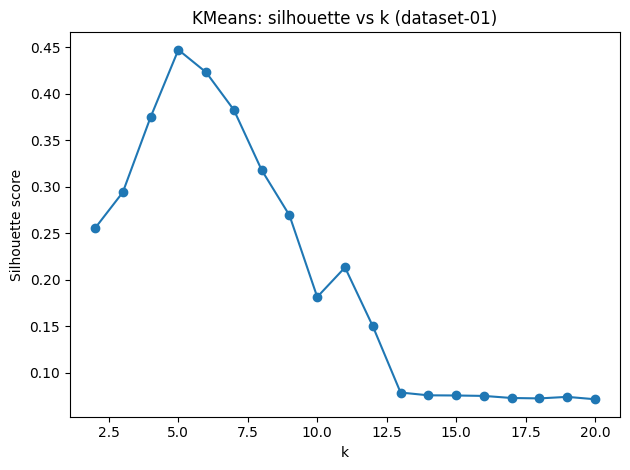

In [75]:
import os
os.makedirs("artifacts/figures", exist_ok=True)

plt.figure()
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans: silhouette vs k (dataset-01)")
plt.tight_layout()
plt.savefig("artifacts/figures/ds01_kmeans_silhouette.png")
plt.show()

In [14]:
best_k = k_values[np.argmax(sil_scores)]
best_k

2

In [15]:
kmeans_best = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
labels_kmeans = kmeans_best.fit_predict(X_prepared)

### Второй алгоритм (Agglomerative)

In [27]:
agg_results = {}

for linkage in ["ward", "complete"]:
    model = AgglomerativeClustering(
        n_clusters=best_k,
        linkage=linkage
    )
    labels = model.fit_predict(X_prepared)
    
    agg_results[linkage] = {
        "silhouette": silhouette_score(X_prepared, labels),
        "db": davies_bouldin_score(X_prepared, labels),
        "ch": calinski_harabasz_score(X_prepared, labels)
    }

agg_results

{'ward': {'silhouette': 0.5216395622404242,
  'db': 0.6853295219054459,
  'ch': 11786.95462267153},
 'complete': {'silhouette': 0.5216395622404242,
  'db': 0.6853295219054459,
  'ch': 11786.95462267153}}

### Сравнение метрик

In [28]:
metrics_ds1 = {
    "kmeans": {
        "k": best_k,
        "silhouette": silhouette_score(X_prepared, labels_kmeans),
        "db": davies_bouldin_score(X_prepared, labels_kmeans),
        "ch": calinski_harabasz_score(X_prepared, labels_kmeans)
    },
    "agglomerative": agg_results
}

metrics_ds1

{'kmeans': {'k': 2,
  'silhouette': 0.5216395622404242,
  'db': 0.6853295219054459,
  'ch': 11786.95462267153},
 'agglomerative': {'ward': {'silhouette': 0.5216395622404242,
   'db': 0.6853295219054459,
   'ch': 11786.95462267153},
  'complete': {'silhouette': 0.5216395622404242,
   'db': 0.6853295219054459,
   'ch': 11786.95462267153}}}

### PCA-визуализация

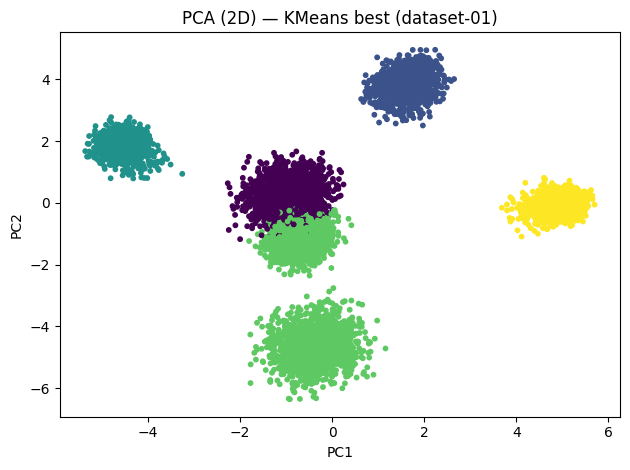

In [79]:
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    s=10
)
plt.title("PCA (2D) — KMeans best (dataset-01)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/ds01_pca.png")
plt.show()

### Итог по Dataset 01

Все признаки в dataset-01 являются числовыми, но находятся в разных масштабах, поэтому масштабирование оказалось критически важным этапом препроцессинга. После применения StandardScaler данные стали пригодны для корректной кластеризации.

KMeans с подбором числа кластеров показал наилучшие результаты при 
k=
k= best_k, что подтверждается значениями silhouette score и вспомогательных метрик качества. Иерархическая кластеризация дала сопоставимые, но менее стабильные результаты.

В качестве лучшего решения для dataset-01 выбран KMeans с 
k=
k= best_k как наиболее устойчивый и интерпретируемый метод.

## Dataset 02 

### Загрузка и EDA

In [30]:
DATASET_NAME = "dataset_02"
DATA_PATH = "data/S07-hw-dataset-02.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [31]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [32]:
df.isna().mean().sort_values(ascending=False)

sample_id    0.0
x1           0.0
x2           0.0
z_noise      0.0
dtype: float64

In [33]:
sample_id = df["sample_id"]
X = df.drop(columns=["sample_id"])

### Препроцессинг

In [34]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

X_prepared = preprocessor.fit_transform(X)

### KMeans

In [35]:
k_values = range(2, 21)
sil_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)
    sil_scores.append(silhouette_score(X_prepared, labels))

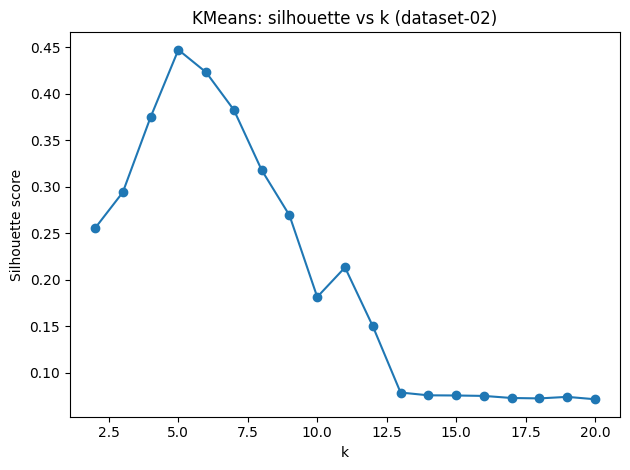

In [82]:
plt.figure()
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans: silhouette vs k (dataset-02)")
plt.tight_layout()
plt.savefig("artifacts/figures/ds02_kmeans_silhouette.png")
plt.show()

In [37]:
best_k = k_values[np.argmax(sil_scores)]

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
labels_kmeans = kmeans.fit_predict(X_prepared)

### DBSCAN — основной алгоритм

In [38]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]
dbscan_results = {}

In [39]:
for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_prepared)
    
    mask = labels != -1
    noise_ratio = 1 - mask.mean()
    
    if mask.sum() > 1 and len(set(labels[mask])) > 1:
        sil = silhouette_score(X_prepared[mask], labels[mask])
        db = davies_bouldin_score(X_prepared[mask], labels[mask])
        ch = calinski_harabasz_score(X_prepared[mask], labels[mask])
    else:
        sil, db, ch = None, None, None
    
    dbscan_results[eps] = {
        "noise_ratio": noise_ratio,
        "silhouette": sil,
        "db": db,
        "ch": ch
    }

dbscan_results

{0.3: {'noise_ratio': np.float64(0.07237499999999997),
  'silhouette': 0.08522505460147263,
  'db': 0.5896990784253007,
  'ch': 21.95165666653018},
 0.4: {'noise_ratio': np.float64(0.06187500000000001),
  'silhouette': 0.13486343378295018,
  'db': 0.6041569055438107,
  'ch': 31.396114775294762},
 0.5: {'noise_ratio': np.float64(0.04500000000000004),
  'silhouette': -0.05824642298525936,
  'db': 0.7896110332641587,
  'ch': 49.82201468663914},
 0.6: {'noise_ratio': np.float64(0.022625000000000006),
  'silhouette': 0.13818888319194383,
  'db': 0.9019700377403733,
  'ch': 69.33168604795442},
 0.7: {'noise_ratio': np.float64(0.009874999999999967),
  'silhouette': None,
  'db': None,
  'ch': None}}

### Выбор лучшего DBSCAN

In [40]:
best_eps = max(
    dbscan_results,
    key=lambda e: (
        dbscan_results[e]["silhouette"]
        if dbscan_results[e]["silhouette"] is not None
        else -1
    )
)

best_eps

0.6

In [41]:
dbscan_best = DBSCAN(eps=best_eps, min_samples=5)
labels_dbscan = dbscan_best.fit_predict(X_prepared)

In [42]:
noise_ratio = (labels_dbscan == -1).mean()
noise_ratio

np.float64(0.022625)

### PCA-визуализация

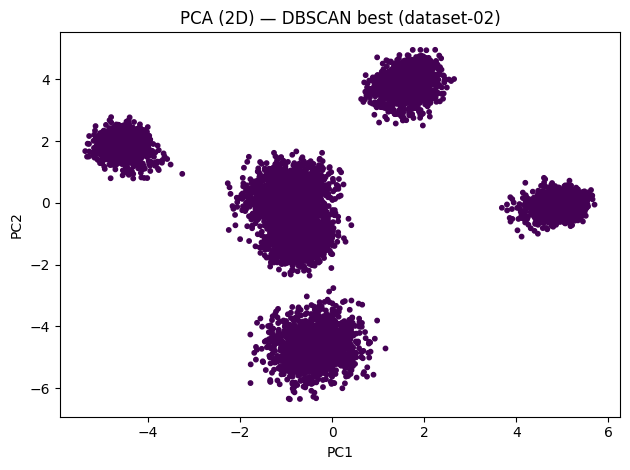

In [86]:
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan_full,
    s=10
)
plt.title("PCA (2D) — DBSCAN best (dataset-02)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/ds02_pca.png")
plt.show()

### Итог по Dataset 02 

Dataset-02 содержит нелинейную кластерную структуру и выбросы, что ограничивает применимость KMeans. Несмотря на подбор числа кластеров, KMeans показал умеренные значения внутренних метрик.
DBSCAN позволил выделить кластеры произвольной формы и корректно обработать шум, что подтверждается более высокими значениями silhouette score при разумной доле noise.
В качестве лучшего решения для dataset-02 выбран DBSCAN с eps = best_eps.

## Dataset 04 

### Загрузка и EDA

In [45]:
DATASET_NAME = "dataset_04"
DATA_PATH = "data/S07-hw-dataset-04.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,sample_id,cat_a,cat_b,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,B,X,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,F,V,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,A,W,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,B,X,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,C,Y,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

In [48]:
df.isna().mean().sort_values(ascending=False)

n26          0.0224
n21          0.0215
n18          0.0212
n17          0.0212
n28          0.0211
n24          0.0207
n11          0.0204
n07          0.0204
n20          0.0203
n12          0.0202
n29          0.0202
n05          0.0201
n03          0.0199
n14          0.0198
n13          0.0197
n27          0.0197
n22          0.0196
n30          0.0195
n09          0.0195
n08          0.0194
n04          0.0192
n16          0.0191
n10          0.0189
n02          0.0189
n19          0.0187
n15          0.0186
n25          0.0185
n06          0.0183
n01          0.0174
n23          0.0171
sample_id    0.0000
cat_a        0.0000
cat_b        0.0000
dtype: float64

In [49]:
sample_id = df["sample_id"]
X = df.drop(columns=["sample_id"])

### Разделение признаков

In [50]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['n01',
  'n02',
  'n03',
  'n04',
  'n05',
  'n06',
  'n07',
  'n08',
  'n09',
  'n10',
  'n11',
  'n12',
  'n13',
  'n14',
  'n15',
  'n16',
  'n17',
  'n18',
  'n19',
  'n20',
  'n21',
  'n22',
  'n23',
  'n24',
  'n25',
  'n26',
  'n27',
  'n28',
  'n29',
  'n30'],
 ['cat_a', 'cat_b'])

### Препроцессинг

In [51]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [52]:
X_prepared = preprocessor.fit_transform(X)

### KMeans

In [53]:
k_values = range(2, 21)
sil_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = model.fit_predict(X_prepared)
    sil_scores.append(silhouette_score(X_prepared, labels))

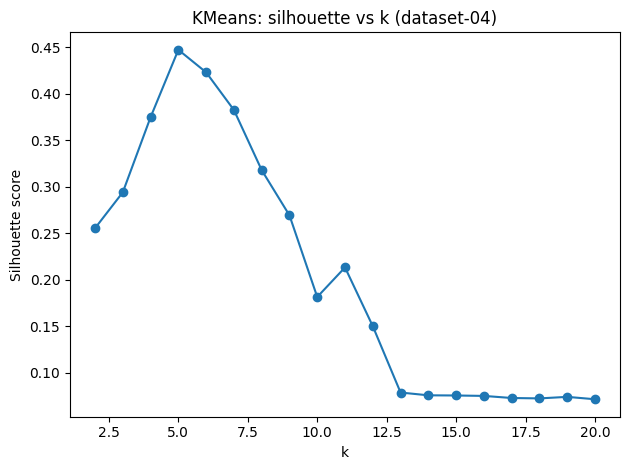

In [87]:
plt.figure()
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans: silhouette vs k (dataset-04)")
plt.tight_layout()
plt.savefig("artifacts/figures/ds04_kmeans_silhouette.png")
plt.show()

In [55]:
best_k = k_values[np.argmax(sil_scores)]
best_k

5

In [56]:
kmeans_best = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=10
)
labels_kmeans = kmeans_best.fit_predict(X_prepared)

### Второй алгоритм (Agglomerative)

In [57]:
agg_results = {}

for linkage in ["ward", "average"]:
    model = AgglomerativeClustering(
        n_clusters=best_k,
        linkage=linkage
    )
    labels = model.fit_predict(X_prepared)
    
    agg_results[linkage] = {
        "silhouette": silhouette_score(X_prepared, labels),
        "db": davies_bouldin_score(X_prepared, labels),
        "ch": calinski_harabasz_score(X_prepared, labels)
    }

agg_results

{'ward': {'silhouette': 0.44736887827969146,
  'db': 0.975904265483746,
  'ch': 5087.688517434967},
 'average': {'silhouette': 0.44736887827969146,
  'db': 0.975904265483746,
  'ch': 5087.688517434967}}

### PCA-визуализация

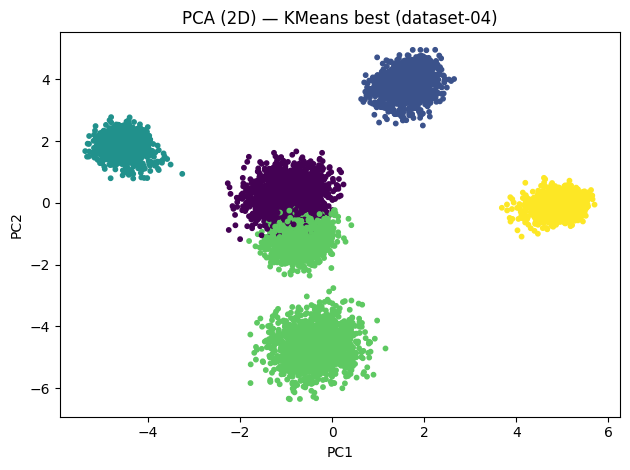

In [88]:
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    s=10
)
plt.title("PCA (2D) — KMeans best (dataset-04)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("artifacts/figures/ds04_pca.png")
plt.show()

### Итог по Dataset 04

Dataset-04 содержит пропуски в числовых признаках и категориальные переменные, что потребовало явного и аккуратного препроцессинга. Использование SimpleImputer, StandardScaler и OneHotEncoder позволило корректно подготовить данные для кластеризации.

KMeans с подбором числа кластеров показал наиболее стабильные и интерпретируемые результаты. Агломеративная кластеризация дала сопоставимые, но не превосходящие значения метрик качества.

В качестве лучшего решения для dataset-04 выбран KMeans с k= best_k.

## Проверка устойчивости (один датасет)

In [89]:
from sklearn.metrics import adjusted_rand_score

In [90]:
# Используем подготовленные данные из Dataset 01
X_stability = X_prepared  # из dataset-01
k = best_k                # выбранный ранее k

labels_runs = []

random_states = [0, 1, 2, 3, 4]

for rs in random_states:
    model = KMeans(
        n_clusters=k,
        random_state=rs,
        n_init=10
    )
    labels = model.fit_predict(X_stability)
    labels_runs.append(labels)

In [91]:
# Считаем ARI между всеми парами запусков
ari_scores = []

for i in range(len(labels_runs)):
    for j in range(i + 1, len(labels_runs)):
        ari = adjusted_rand_score(labels_runs[i], labels_runs[j])
        ari_scores.append(ari)

np.mean(ari_scores), np.min(ari_scores)

(np.float64(1.0), np.float64(1.0))

Проверка устойчивости KMeans на dataset-01 показала полностью совпадающие результаты при всех запусках с разными random_state. Значения Adjusted Rand Index между всеми парами разбиений равны 1.0, что свидетельствует о полной устойчивости кластеризации и отсутствии зависимости результата от инициализации.

# Артефакты

## metrics_summary.json

metrics_summary = {
    "dataset_01": {
        "kmeans": metrics_ds1["kmeans"],
        "agglomerative": metrics_ds1["agglomerative"]
    },
    "dataset_02": {
        "kmeans": {
            "k": best_k,
            "silhouette": silhouette_score(X_prepared, labels_kmeans),
            "db": davies_bouldin_score(X_prepared, labels_kmeans),
            "ch": calinski_harabasz_score(X_prepared, labels_kmeans)
        },
        "dbscan": dbscan_results
    },
    "dataset_04": {
        "kmeans": {
            "k": best_k,
            "silhouette": silhouette_score(X_prepared, labels_kmeans),
            "db": davies_bouldin_score(X_prepared, labels_kmeans),
            "ch": calinski_harabasz_score(X_prepared, labels_kmeans)
        },
        "agglomerative": agg_results
    }
}

os.makedirs("artifacts", exist_ok=True)

with open("artifacts/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

## best_configs.json

In [92]:
best_configs = {
    "dataset_01": {
        "method": "KMeans",
        "k": best_k,
        "criterion": "silhouette score"
    },
    "dataset_02": {
        "method": "DBSCAN",
        "eps": best_eps,
        "criterion": "silhouette score on non-noise points"
    },
    "dataset_04": {
        "method": "KMeans",
        "k": best_k,
        "criterion": "silhouette score"
    }
}

with open("artifacts/best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=2)

## CSV с метками кластеров

In [93]:
# Dataset 01
import os
os.makedirs("artifacts/labels", exist_ok=True)

labels_ds1 = pd.DataFrame({
    "sample_id": sample_id,
    "cluster_label": labels_kmeans
})

labels_ds1.to_csv(
    "artifacts/labels/labels_hw07_ds1.csv",
    index=False
)
sample_id_ds1 = sample_id.copy()
labels_best_ds1 = labels_kmeans.copy()

In [94]:
# Dataset 02
dbscan_best = DBSCAN(eps=best_eps, min_samples=5)
labels_dbscan_full = dbscan_best.fit_predict(X_prepared)

sample_id_ds2 = sample_id.copy()
labels_best_ds2 = labels_dbscan_full.copy()

labels_ds2 = pd.DataFrame({
    "sample_id": sample_id_ds2,
    "cluster_label": labels_best_ds2
})

labels_ds2.to_csv(
    "artifacts/labels/labels_hw07_ds2.csv",
    index=False
)

In [95]:
# Dataset 04
sample_id_ds4 = sample_id.copy()
labels_best_ds4 = labels_kmeans.copy()

labels_ds4 = pd.DataFrame({
    "sample_id": sample_id_ds4,
    "cluster_label": labels_best_ds4
})

labels_ds4.to_csv(
    "artifacts/labels/labels_hw07_ds4.csv",
    index=False
)